In [2]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import sobel, gaussian_filter
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks
from scipy.optimize import curve_fit


from chars import greek, phys


In [3]:
cwd = Path(os.getcwd())

# results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'feature testing' / 't=26.0nm Λ=500nm FF=0.76 N=75' / 'data'

results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'WS₂, SiO₂, Si' / 't=18.0nm Λ=500nm FF=0.84 N=75' / 'data'


files = sorted(os.listdir(results_dir))
file_R = results_dir / files[4]
file_R_sub = results_dir / files[5]
print(file_R)


C:\Users\whamp\PycharmProjects\research_project\WS2_Grating_Eamonn\Results\WS₂, SiO₂, Si\t=18.0nm Λ=500nm FF=0.84 N=75\data\WS₂, SiO₂, Si - t=18.0nm Λ=500nm FF=0.84_R_sub.csv


In [4]:
R = pd.read_csv(file_R, index_col=0)
Rsub = pd.read_csv(file_R_sub, index_col=0)

signalR = (R - Rsub) / Rsub
signalR = (signalR - np.min(signalR)) / (np.max(signalR) - np.min(signalR))

signalR.describe()

,-5.000000000000000000e+00,-4.864864864864864913e+00,-4.729729729729729826e+00,-4.594594594594594739e+00,-4.459459459459459651e+00,-4.324324324324324564e+00,-4.189189189189189477e+00,-4.054054054054054390e+00,-3.918918918918918859e+00,-3.783783783783783772e+00,...,3.783783783783784216e+00,3.918918918918919303e+00,4.054054054054054390e+00,4.189189189189189477e+00,4.324324324324324564e+00,4.459459459459459651e+00,4.594594594594594739e+00,4.729729729729729826e+00,4.864864864864864913e+00,5.000000000000000000e+00
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.327463,0.309657,0.293935,0.279307,0.264159,0.250787,0.240967,0.232193,0.221710,0.214354,...,0.214354,0.221710,0.232193,0.240967,0.250787,0.264159,0.279307,0.293935,0.309657,0.327463
std,0.158482,0.156259,0.154541,0.153006,0.150349,0.148387,0.146941,0.144541,0.140126,0.139107,...,0.139107,0.140126,0.144541,0.146941,0.148387,0.150349,0.153006,0.154541,0.156259,0.158482
min,0.099518,0.093637,0.088546,0.083038,0.078181,0.073953,0.069405,0.065353,0.061655,0.057822,...,0.057822,0.061655,0.065353,0.069405,0.073953,0.078181,0.083038,0.088546,0.093637,0.099518
25%,0.226243,0.211702,0.187672,0.178312,0.161298,0.145269,0.142943,0.144091,0.144486,0.132411,...,0.132411,0.144486,0.144091,0.142943,0.145269,0.161298,0.178312,0.187672,0.211702,0.226243
50%,0.325668,0.302878,0.289196,0.269220,0.250970,0.234261,0.218936,0.204859,0.193428,0.186420,...,0.186420,0.193428,0.204859,0.218936,0.234261,0.250970,0.269220,0.289196,0.302878,0.325668
75%,0.377170,0.352234,0.330289,0.309683,0.290878,0.273597,0.258003,0.243282,0.229602,0.216839,...,0.216839,0.229602,0.243282,0.258003,0.273597,0.290878,0.309683,0.330289,0.352234,0.377170
max,1.000000,0.977863,0.956082,0.934698,0.913755,0.893296,0.873370,0.854029,0.835334,0.817351,...,0.817351,0.835334,0.854029,0.873370,0.893296,0.913755,0.934698,0.956082,0.977863,1.000000


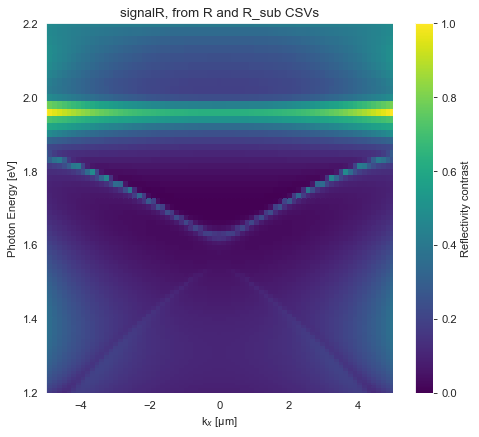

In [5]:
N=75
lbda_min = 1240 / 2.2 # y limits
lbda_max = 1240 / 1.2
lbda = np.linspace(lbda_min/1000,lbda_max/1000,N)
N_k=N
# k_scan=np.linspace(-6.7,6.7,N_k) #mu-1
kmax=5
k_scan=np.linspace(-kmax,kmax,N_k) #mu-1
ky=0.000
title_name = 'signalR, from R and R_sub CSVs'

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()

(75, 75)


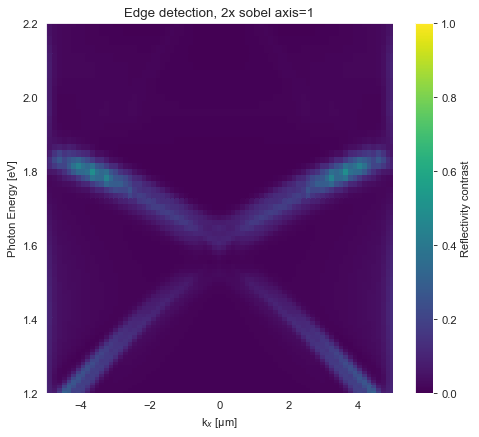

<Figure size 640x480 with 0 Axes>

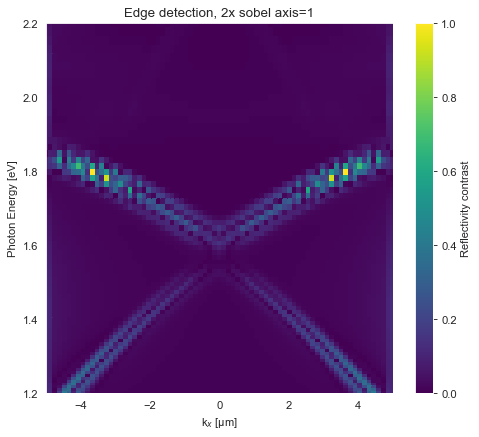

In [6]:
cwd=Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)


data_array = np.asarray(signalR)
sobel_x = sobel(data_array, axis=0)  # Sobel in the x-direction
sobel_y = sobel(data_array, axis=1)  # Sobel in the y-direction

sobel_y = sobel(sobel_y, axis=1)  # Sobel in the y-direction

# Calculate the gradient magnitude (combined Sobel in x and y)
sobel_magnitude = np.hypot(sobel_x, sobel_y)

edge_magnitude = np.abs(sobel_y)

# Normalize edge magnitude for better visualization
edge_magnitude_normalized = edge_magnitude / np.max(edge_magnitude)

# Apply Gaussian blur to smooth the edges (adjust sigma as needed for desired blur amount)
sigma = 0.8
edge_magnitude_blurred = gaussian_filter(edge_magnitude_normalized, sigma=sigma)


print(edge_magnitude.shape)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,edge_magnitude_blurred,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title='Edge detection, 2x sobel axis=1')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect_gaussian.png', dpi=150)
plt.show()
plt.clf()

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,edge_magnitude_normalized,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title='Edge detection, 2x sobel axis=1')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect_normal.png', dpi=150)




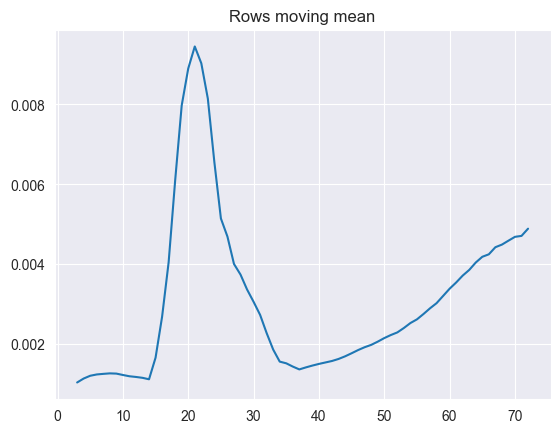

In [7]:

# find the coords of above and below the top mode, identify the gap
line_y_max = [np.max(row)*np.mean(row)/np.sum(row) for row in edge_magnitude_normalized]

# apply 3 point moving average to line_y_max

pd_line_y_max = pd.Series(line_y_max)
# pd_line_y_max.plot(title='Max val of rows')

# Apply a 3-point moving average to smooth the data
pd_line_y_max_smoothed = pd_line_y_max.rolling(window=6, center=True).mean()
pd_line_y_max_smoothed.plot(title='Rows moving mean')

plt.savefig(testpath / 'lineprofile.png', dpi=150)


Peak at 21 - before=14, after=37, diff 0.008074782228564044
Found peak at idx 21


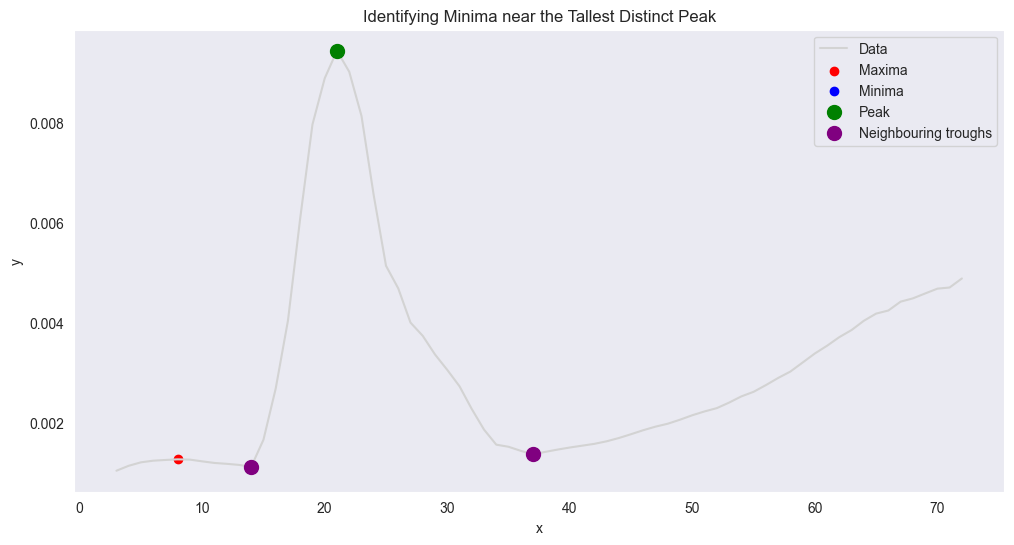

In [8]:

# Use the Series index as x values
y = pd_line_y_max_smoothed
x = pd_line_y_max_smoothed.index

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)  # Invert y to find minima

# peaks_df = pd.Series(peaks)
# troughs_df = pd.Series(troughs)
# pt_df = pd.DataFrame({'peaks':peaks_df, 'troughs':troughs_df})
# print(pt_df)

minima_indices = troughs
min_peak_trough_diff = 0.6

max_peak = None # [loc, comparable diff]
min_troughs = None # [loc1, loc2]

for _,peak in enumerate(peaks):
    before_trough = troughs[troughs < peak].max() if (troughs < peak).any() else None
    after_trough = troughs[troughs > peak].min() if (troughs > peak).any() else None
    
    if None in [before_trough, after_trough]:
        continue
    before_trough = int(before_trough)
    after_trough = int(after_trough)
    
    diff1, diff2 = y[peak] - y[before_trough], y[peak] - y[after_trough]
    diff_min = np.min([diff1, diff2]) # find min proximity in y to trough
    
    if max_peak == None or max_peak[1] < diff_min:
        max_peak = [peak,diff_min]
        min_troughs = [before_trough, after_trough]
    
    print(f"Peak at {peak} - before={before_trough}, after={after_trough}, diff {diff_min}")

print(f"Found peak at idx {max_peak[0]}")
    


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Data', color='lightgray')
plt.scatter(x[peaks], y[peaks], color='red', label='Maxima')
plt.scatter(x[minima_indices], y[minima_indices], color='blue', label='Minima', zorder=5)
plt.scatter(x[max_peak[0]], y[max_peak[0]], color='green', label='Peak', s=100, zorder=10)
plt.scatter([x[min_troughs[0]], x[min_troughs[1]]], [y[min_troughs[0]], y[min_troughs[1]]], color='purple', label='Neighbouring troughs', s=100, zorder=10)
plt.title('Identifying Minima near the Tallest Distinct Peak')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.savefig(testpath / 'peaks.png', dpi=150)
plt.show()

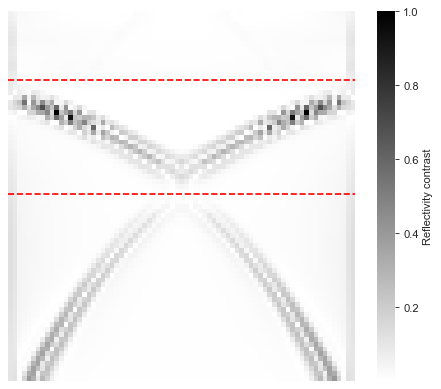

In [9]:
# Create a new figure for the heatmap
plt.figure(figsize=(7, 6), dpi=80)

# Use seaborn to create a heatmap
sns.heatmap(edge_magnitude_normalized, cmap='binary', cbar_kws={'label': 'Reflectivity contrast'}, 
            xticklabels=False, yticklabels=False)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

plt.minorticks_on()

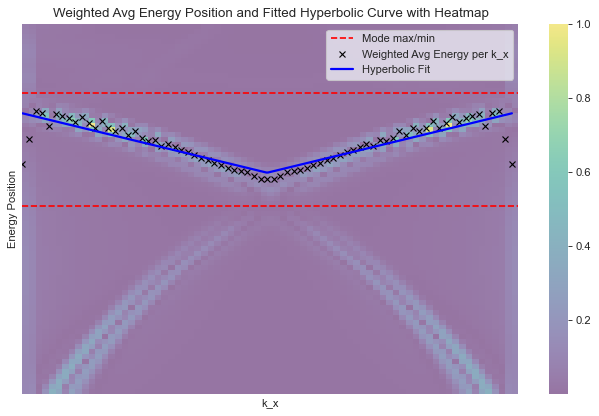

Fitted parameters:
h = 30.1866, a = -0.3087, b = 0.0000, k = 37.0000, v = 0.0340


In [11]:
v1 = 0.034  # eV.um
U = 0.090  # eV
E0 = 1.47  # eV
# v, b, h initial guesses

def hyperbolic_model(x, h, a, b, k, v):
    return h + a * np.sqrt(b**2 + (v*(x - k))**2)

# Directory setup
cwd = Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))  # y-axis indices (energies)

    # Find the threshold for the top 25% quantile
    quantile_threshold = np.percentile(column, 80)

    # Filter values to only those above the 75th percentile
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]  # Corresponding y indices

    # Calculate the weighted average for the filtered values
    if np.sum(filtered_column) > 0:  # Avoid division by zero if the filtered column is empty
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)  # Adjust by y_min to reflect the original position
    else:
        # If no values exceed the threshold, use a fallback value
        y_positions.append((y_max + y_min) / 2)

# Convert to arrays for curve fitting
x_data = np.array(x_indices)
y_data = np.array(y_positions)

# Perform curve fitting (using hyperbolic fit)
initial_guess = [E0, 1, U, np.mean(x_data), v1]
popt, pcov = curve_fit(hyperbolic_model, x_data, y_data, p0=initial_guess)

# Generate smooth x-values for plotting the fitted curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = hyperbolic_model(x_smooth, *popt)

# Overlay the weighted average data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'x', color='black', markersize=6, label='Weighted Avg Energy per k_x')
plt.plot(x_smooth, y_fit, color='blue', linewidth=2, label='Hyperbolic Fit')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Weighted Avg Energy Position and Fitted Hyperbolic Curve with Heatmap')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
h, a, b, k, v = popt
print(f"Fitted parameters:\nh = {h:.4f}, a = {a:.4f}, b = {b:.4f}, k = {k:.4f}, v = {v1:.4f}")


(75,) (75,)


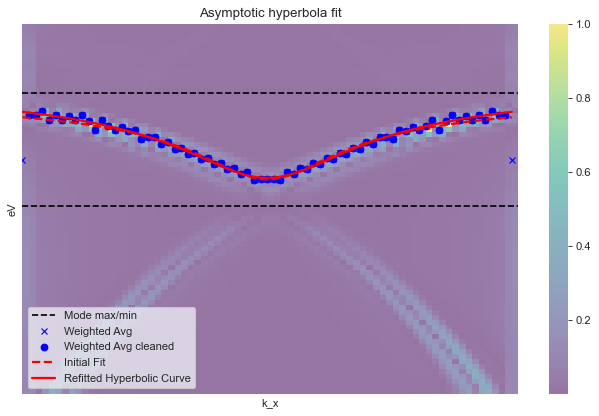

Fitted parameters (initial hyperbolic):
a = 0.3001, b = 37.0001, L = 6476.4741, M = 0.0995, F = 1081.5357, B = 0.2979, sign = -0.9999
Fitted parameters (cleaned hyperbolic):
a = 0.3227, b = 37.0000, L = 6882.5150, M = 0.1364, F = 1228.0810, B = 0.3211, sign = -0.9999


In [22]:

# Define the hyperbolic asymptotic model for curve fitting
def hyperbola_asymptotic(x, a, b, L, M, F, B, sign):
    """
    Hyperbolic asymptotic fit model
    :param x: x
    :param a: shift y
    :param b: shift x
    :param L: multiply y
    :param M: multiply x
    :param F: pointyness
    :param B: asymptote in y
    :param sign: u or n shape
    :return: g(x) func result
    """
    xbM = ((x - b) ** 2) / M
    f_x = sign*np.sqrt(np.abs( (F + xbM) ))
    g_x = a + ( f_x / (1 + (np.abs(f_x) / B)) )
    return g_x * L

# Directory setup
cwd = Path().cwd()
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)

# Create a heatmap (visualization)
plt.figure(figsize=(10, 6), dpi=80)
sns.heatmap(edge_magnitude_normalized, cmap='viridis', xticklabels=False, yticklabels=False, alpha=0.5)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='black', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='black', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min, y_max = min_troughs[0], min_troughs[1]
data_region = edge_magnitude_normalized[y_min:y_max, :]
x_indices = np.arange(data_region.shape[1])

# Calculate weighted average energy positions for the top 25 quantile values
y_positions = []
for x in x_indices:
    column = data_region[:, x]
    y_indices = np.arange(len(column))

    quantile_threshold = np.percentile(column, 95)
    filtered_indices = np.where(column >= quantile_threshold)[0]
    filtered_column = column[filtered_indices]
    filtered_y_indices = y_indices[filtered_indices]

    if np.sum(filtered_column) > 0:
        weighted_avg = np.sum(filtered_column * filtered_y_indices) / np.sum(filtered_column)
        y_positions.append(weighted_avg + y_min)
    else:
        y_positions.append((y_max + y_min) / 2)

x_data = np.array(x_indices)
y_data = np.array(y_positions)

print(np.shape(y_data), np.shape(x_data))

N = 75

initial_guess = \
    [0.3, N / 2, 7000, 0.3, 500, 0.3, -1] # a = 0.2689, b = 37.0000, L = 6601.1831, M = 0.3102, F = 538.8776, B = 0.2672, sign = -1.0000
bounds = \
    ([-50, 0, 100, 0, 1, 0, -1], 
     [50, N, 10000, 10, 10000, 100, 1])

# Perform hyperbolic curve fitting
popt, pcov = curve_fit(hyperbola_asymptotic, x_data, y_data, 
                       p0=initial_guess, bounds=bounds, maxfev=10000)

# Generate smooth x-values for plotting the fitted hyperbolic curve
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_fit = hyperbola_asymptotic(x_smooth, *popt)

# Calculate residuals and identify outliers
residuals = y_data - hyperbola_asymptotic(x_data, *popt)
threshold = 1.5 * np.std(residuals)
outlier_indices = np.abs(residuals) > threshold
x_data_cleaned = x_data[~outlier_indices]
y_data_cleaned = y_data[~outlier_indices]

initial_guess_2 = popt

# Refit the hyperbolic model to the cleaned data
popt_cleaned, pcov_cleaned = curve_fit(hyperbola_asymptotic, x_data_cleaned, y_data_cleaned, p0=initial_guess_2, bounds=bounds, maxfev=10000)
y_fit_cleaned = hyperbola_asymptotic(x_smooth, *popt_cleaned)

# Overlay the data and the fitted hyperbolic curve on the heatmap
plt.plot(x_data, y_data, 'bx', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned, y_data_cleaned, 'bo', markersize=6, label='Weighted Avg cleaned')
plt.plot(x_smooth, y_fit, 'r--', linewidth=2, label='Initial Fit')
plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')



# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()
plt.minorticks_on()
plt.title('Asymptotic hyperbola fit')
plt.savefig(testpath / 'hyperbolic_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()

# Print fitted parameters for reference
a, b, L, M, F, B, sign = popt
print(f"Fitted parameters (initial hyperbolic):\na = {a:.4f}, b = {b:.4f}, L = {L:.4f}, M = {M:.4f}, F = {F:.4f}, B = {B:.4f}, sign = {sign:.4f}")

a_cleaned, b_cleaned, L_cleaned, M_cleaned, F_cleaned, B_cleaned, sign_cleaned = popt_cleaned
print(f"Fitted parameters (cleaned hyperbolic):\na = {a_cleaned:.4f}, b = {b_cleaned:.4f}, L = {L_cleaned:.4f}, M = {M_cleaned:.4f}, F = {F_cleaned:.4f}, B = {B_cleaned:.4f}, sign = {sign:.4f}")


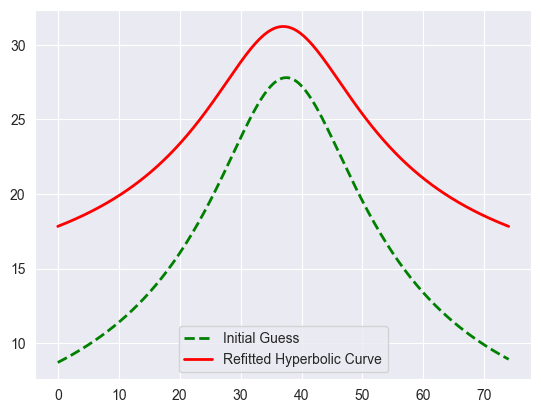

In [24]:
# 'a = 0.2689, b = 37.0000, L = 6601.1831, M = 0.3102, F = 538.8776, B = 0.2672, sign = -1.0000'

# Calculate the initial guess for the hyperbolic curve
y_initial_guess = hyperbola_asymptotic(x_smooth, *initial_guess)  # Calculate initial guess
plt.plot(x_smooth, y_initial_guess, 'g--', linewidth=2, label='Initial Guess')  # Add this line
plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Refitted Hyperbolic Curve')
plt.legend()



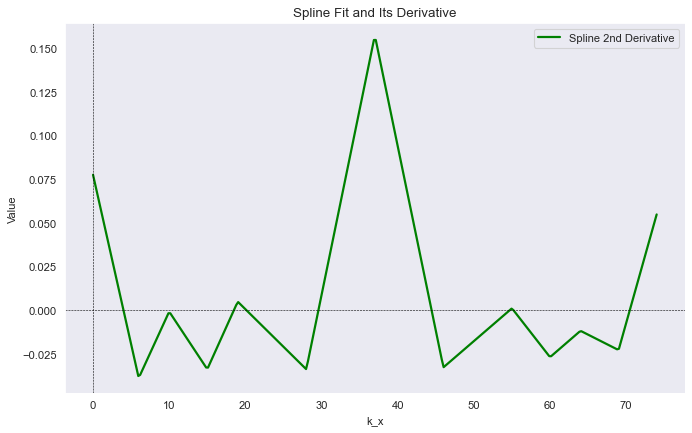

In [41]:


# Generate smooth x-values for plotting the spline and its derivative
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)

# Calculate the spline values and its derivative
spline_fit_values = -spline_fit(x_smooth)
spline_derivative = -spline_fit.derivative()(x_smooth)
spline_derivative_2 = -spline_fit.derivative(n=2)(x_smooth)

# Create a new figure for plotting the spline and its derivative
plt.figure(figsize=(10, 6), dpi=80)

# Plot the spline fit
# plt.plot(x_smooth, spline_fit_values, 'b-', label='Spline Fit', linewidth=2)

# Plot the derivative of the spline
# plt.plot(x_smooth, spline_derivative, 'r-', label='Spline Derivative', linewidth=2)
plt.plot(x_smooth, spline_derivative_2, 'g-', label='Spline 2nd Derivative', linewidth=2)

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('Value')
plt.title('Spline Fit and Its Derivative')
plt.axhline(0, color='black', lw=0.5, linestyle='--')  # Add a horizontal line at y=0 for reference
plt.axvline(0, color='black', lw=0.5, linestyle='--')  # Add a vertical line at x=0 for reference
plt.legend()
plt.grid()
plt.show()


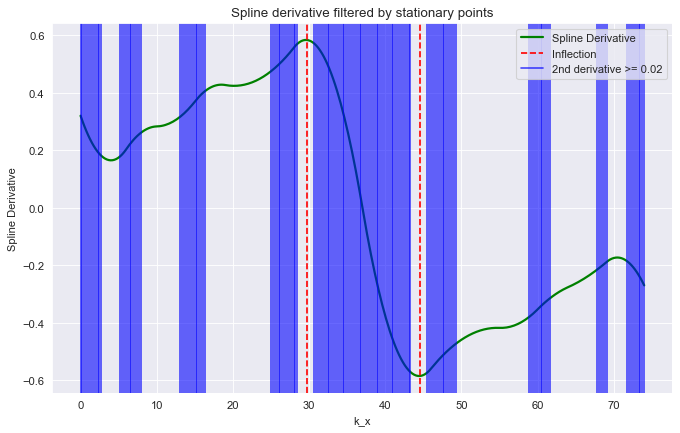

Inflection points at k_x = -1.04 and k_x = 0.94
Average = 0.99
Average inflection in plot coordinates: 30.08, 44.92


In [50]:
# identify stationary points

inflection_threshold = 0.02

# Generate smooth x-values for evaluating derivatives
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)

# Calculate the first and second derivatives of the spline
spline_derivative = spline_fit.derivative()  # First derivative of the spline
spline_derivative_2 = spline_fit.derivative(n=2)  # Second derivative of the spline

# Evaluate the derivatives at x_smooth points
first_derivative_values = spline_derivative(x_smooth)
second_derivative_values = spline_derivative_2(x_smooth)

# Filter x_smooth and first_derivative_values for the range where |second_derivative| < 0.15
mask = np.abs(second_derivative_values) < inflection_threshold
x_filtered = x_smooth[mask]
first_derivative_filtered = first_derivative_values[mask]

# Find inflection points by locating the max/min of the first derivative within the filtered range
lhs_inflection_index = np.argmax(first_derivative_filtered)  # Index of the maximum in the filtered derivative
rhs_inflection_index = np.argmin(first_derivative_filtered)  # Index of the minimum in the filtered derivative

# Map indices back to x values for inflection points
lhs_inflection = x_filtered[lhs_inflection_index]
rhs_inflection = x_filtered[rhs_inflection_index]

# Identify points where |second_derivative| >= 0.15 for axvlines
outlier_x = x_smooth[np.abs(second_derivative_values) >= inflection_threshold]

# Plot the derivative of the spline along with the inflection points and outlier regions
plt.figure(figsize=(10, 6), dpi=80)
plt.plot(x_smooth, first_derivative_values, color='green', linewidth=2, label='Spline Derivative')

# Add vertical lines for inflection points
plt.axvline(x=lhs_inflection, color='red', linestyle='--', label='Inflection')
plt.axvline(x=rhs_inflection, color='red', linestyle='--')

# Add vertical lines for regions where |second_derivative| >= 0.15
for x in outlier_x:
    plt.axvline(x=x, color='blue', linestyle='-', alpha=0.7, label=f'2nd derivative >= {inflection_threshold}' if x == outlier_x[0] else "")

# Configure plot
plt.legend()
plt.xlabel('k_x')  # Label for x-axis
plt.ylabel('Spline Derivative')  # Label for y-axis
plt.title('Spline derivative filtered by stationary points')
plt.grid(True)
plt.savefig(testpath / 'spline_derivative_inflections_with_outliers.png', dpi=150)
plt.show()

# Convert inflection points to k_x coordinates and calculate average
k_lhs = -5 + (lhs_inflection / 75) * 10
k_rhs = -5 + (rhs_inflection / 75) * 10
k_avg = (abs(k_lhs) + abs(k_rhs)) / 2

# Average inflection in plot coordinates
avg_inflection = ((k_avg + 5) / 10) * 75
avg_inflection_neg = ((-k_avg + 5) / 10) * 75

# Print results
print(f"Inflection points at k_x = {k_lhs:.2f} and k_x = {k_rhs:.2f}")
print(f"Average = {k_avg:.2f}")
print(f"Average inflection in plot coordinates: {avg_inflection_neg:.2f}, {avg_inflection:.2f}")


Inflection points at x = 29.70 and x = 44.55


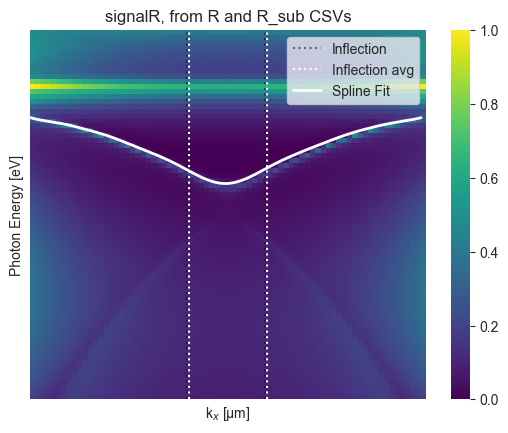

In [51]:
# fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
# pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='viridis',clim=(0,1))
# axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# # y_eV = 1.45    # reference line at 1.45eV
# # axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
# cbar =fig.colorbar(pcm,location='right')
# cbar.set_label('Reflectivity contrast')
# # plt.minorticks_on()
sns.heatmap(signalR, cmap='viridis', xticklabels=False, yticklabels=False, alpha=1)

plt.axvline(x=lhs_inflection, color='black', linestyle=':', label='Inflection', alpha=0.5)
plt.axvline(x=rhs_inflection, color='black', linestyle=':', alpha=0.5)

plt.axvline(x=avg_inflection, color='w', linestyle=':', label='Inflection avg')
plt.axvline(x=avg_inflection_neg, color='w', linestyle=':')

plt.plot(x_smooth, y_fit_spline, 'w-', linewidth=2, label='Spline Fit')

plt.legend()

plt.xlabel(f'k$_x$ [{greek.mu}m]')
plt.ylabel('Photon Energy [eV]')

plt.title(title_name)

final = testpath / 'final.png'
plt.savefig(final, dpi=150)

print(f"Inflection points at x = {lhs_inflection:.2f} and x = {rhs_inflection:.2f}")

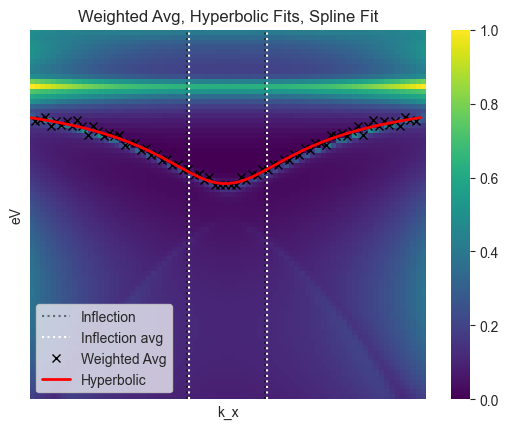

In [55]:
sns.heatmap(signalR, cmap='viridis', xticklabels=0, yticklabels=0, alpha=1)

plt.axvline(x=lhs_inflection, color='black', linestyle=':', label='Inflection', alpha=0.5)
plt.axvline(x=rhs_inflection, color='black', linestyle=':', alpha=0.5)

plt.axvline(x=avg_inflection, color='w', linestyle=':', label='Inflection avg')
plt.axvline(x=avg_inflection_neg, color='w', linestyle=':')

# Overlay the weighted average data and the fitted curves on the heatmap
# plt.plot(x_data, y_data, 'x', markersize=6, label='Weighted Avg')
plt.plot(x_data_cleaned, y_data_cleaned, 'kx', markersize=6, label='Weighted Avg')

plt.plot(x_smooth, y_fit_cleaned, 'r-', linewidth=2, label='Hyperbolic')

# Configure the plot
plt.xlabel('k_x')
plt.ylabel('eV')
plt.legend()

plt.title('Weighted Avg, Hyperbolic Fits, Spline Fit')
plt.savefig(testpath / 'hyperbolic_and_spline_fit_with_weighted_avg_and_heatmap.png', dpi=150)
plt.show()